# Fase 3b · Eventos

Asociación exploratoria (Spearman) entre cada serie mensual y un indicador binario de la ventana ±3 meses de cada evento, con corrección de Benjamini-Hochberg sobre una única familia de 472 contrastes. Lenguaje no causal (D-09). Resultado: ninguna asociación supera BH.

In [1]:
# Localiza la raíz del repositorio para poder importar `src`
# tanto desde VS Code (cwd=notebooks) como con nbclient (cwd=raíz).
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "pyproject.toml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

In [2]:
import pandas as pd
from src.utils.config import PROJECT_ROOT

relations = pd.read_csv(PROJECT_ROOT / "reports/tables/eventos_relaciones.csv")
print("contrastes:", len(relations))
print(
    "p<0,05 brutos:",
    int((relations["p"] < 0.05).sum()),
    "| q mínimo:",
    round(relations["q"].min(), 4),
)
relations.nsmallest(10, "p")[["evento", "serie", "serie_id", "rho", "p", "q"]]

contrastes: 472
p<0,05 brutos: 22 | q mínimo: 0.2538


,evento,serie,serie_id,rho,p,q
330,Moción de censura,topic,45,0.373995,0.000538,0.253847
274,Moción de censura,topic,39,0.327167,0.002698,0.611809
311,Guerra de Ucrania,topic,42,-0.300795,0.006035,0.611809
105,Elecciones generales 26-J,topic,2,-0.296082,0.006917,0.611809
49,Elecciones generales 26-J,topic,13,-0.282254,0.010195,0.611809
383,Guerra de Ucrania,topic,50,0.280578,0.010672,0.611809
446,COVID-19: estado de alarma,topic,6,-0.274554,0.012553,0.611809
41,Elecciones generales 26-J,topic,12,-0.268106,0.014880,0.611809
17,Elecciones generales 26-J,topic,1,-0.267330,0.015183,0.611809
113,Elecciones generales 26-J,topic,20,-0.256032,0.020248,0.611809


In [3]:
relations.groupby("evento")["rho"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
evento,,,,,,,,
COVID-19: estado de alarma,59.0,-0.076,0.106,-0.275,-0.154,-0.097,-0.008,0.214
Elecciones generales 10-N,59.0,-0.039,0.098,-0.194,-0.111,-0.065,0.017,0.214
Elecciones generales 20-D,59.0,-0.026,0.106,-0.219,-0.113,-0.034,0.039,0.225
Elecciones generales 26-J,59.0,-0.111,0.123,-0.296,-0.188,-0.147,-0.059,0.178
Elecciones generales 28-A,59.0,-0.090,0.086,-0.255,-0.153,-0.106,-0.034,0.139
Guerra de Ucrania,59.0,-0.004,0.124,-0.301,-0.088,-0.004,0.084,0.281
Investidura de 2020,59.0,-0.090,0.094,-0.228,-0.159,-0.105,-0.045,0.184
Moción de censura,59.0,0.039,0.125,-0.192,-0.040,0.047,0.124,0.374


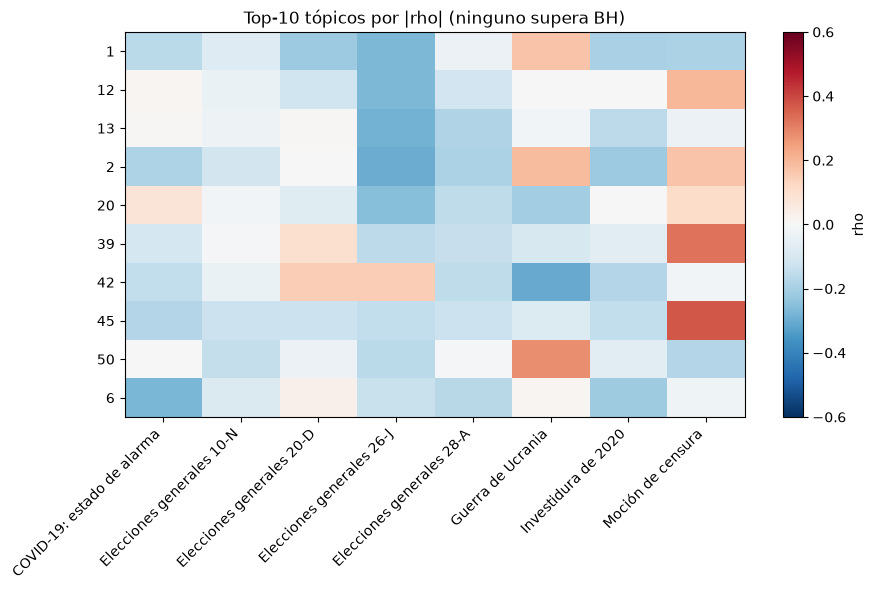

: 

In [ ]:
import matplotlib.pyplot as plt

topics = relations.loc[relations["serie"] == "topic"].copy()
topics["abs_rho"] = topics["rho"].abs()
topics = topics.loc[topics["serie_id"].isin(topics.nlargest(10, "abs_rho")["serie_id"].unique())]
pivot = topics.pivot_table(index="serie_id", columns="evento", values="rho")
figure, axes = plt.subplots(figsize=(10, 5))
image = axes.imshow(pivot.to_numpy(), cmap="RdBu_r", vmin=-0.6, vmax=0.6, aspect="auto")
axes.set_xticks(range(len(pivot.columns)))
axes.set_xticklabels(pivot.columns, rotation=45, ha="right")
axes.set_yticks(range(len(pivot.index)))
axes.set_yticklabels(pivot.index)
figure.colorbar(image, ax=axes, label="rho")
axes.set_title("Top-10 tópicos por |rho| (ninguno supera BH)")
plt.show()